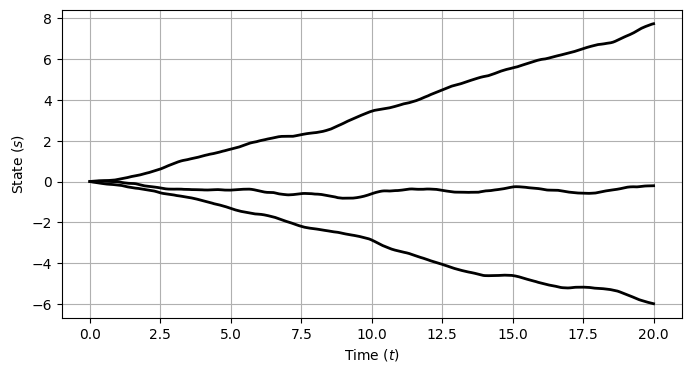

<Figure size 640x480 with 0 Axes>

In [117]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm

# --- Parameters ---
n_steps = 400
dt = 0.05
n_steps = 2000
dt = 0.01
theta = 1.5
sigma_noise = 0.3

n_paths = 3
drifts = [.3, 0.0, -.3]

# --- Simulation (Integrated OU Process) ---
t = np.linspace(0, n_steps * dt, n_steps)
x_paths = np.zeros((n_paths, n_steps))
v_paths = np.zeros((n_paths, n_steps))

for i in range(1, n_steps):
    dw = np.random.normal(0, np.sqrt(dt), n_paths)
    v_paths[:, i] = v_paths[:, i-1] + (-theta * v_paths[:, i-1] * dt + sigma_noise * dw)
    x_paths[:, i] = x_paths[:, i-1] + (v_paths[:, i] + drifts) * dt


# --- Visualization 2D ---
fig = plt.figure(figsize=(8, 4))
ax = fig.add_subplot()

# Reference paths on the ground
for i in range(n_paths):
    ax.plot(t, x_paths[i], 0, color='black', lw=2, ls='-')

# Colorbar
# cbar = fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10, pad=0.1)
# cbar.set_label('GMM Probability Density')

# Axis formatting
# ax.set_title(f'GMM Trajectories (Higher Variance, Viridis Map)\n$\sigma_{{prob}}$ = {prob_sigma}', fontsize=14)
ax.set_xlabel(r'Time ($t$)')
ax.set_ylabel(r'State ($s$)')
ax.grid()
plt.show()
plt.savefig("Plot2D_Trajectories.svg")
plt.savefig("Plot2D_Trajectories.png")

In [112]:
# --- GMM Surface Calculation ---
# Wider y_grid to accommodate higher variance
y_grid = np.linspace(-10, 10, 1000)
T_mesh, Y_mesh = np.meshgrid(t, y_grid)
Z_gmm = np.zeros_like(T_mesh)

prob_sigma = 1.5

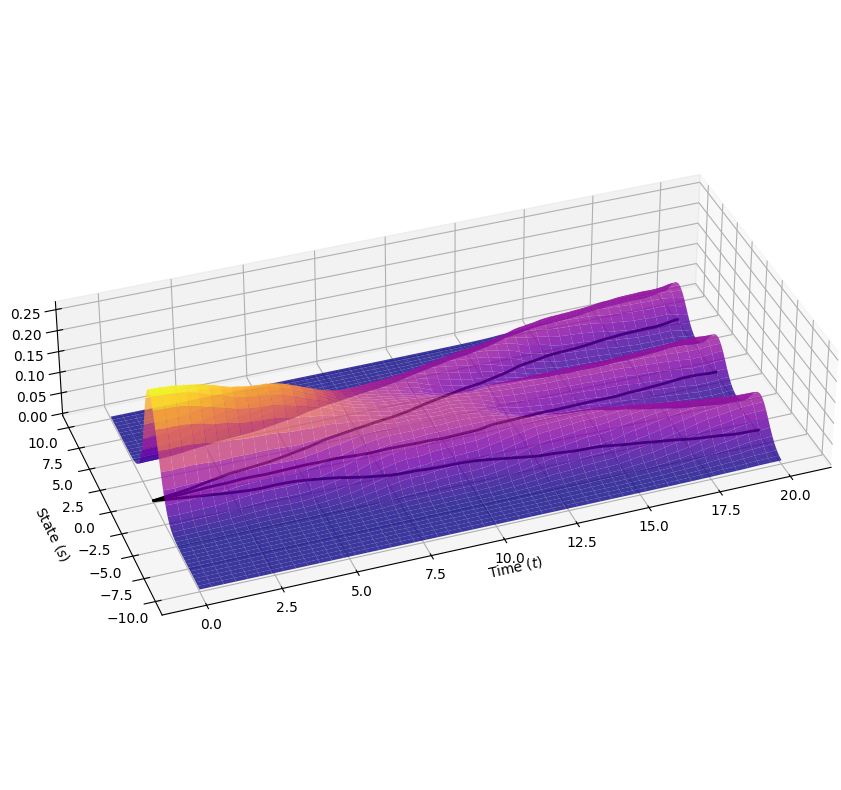

<Figure size 640x480 with 0 Axes>

In [113]:
weights = [0.33, 0.33, 0.33]

for i in range(n_paths):
    mu_t = x_paths[i, :] 
    # Gaussian Component
    component_pdf = (1 / (prob_sigma * np.sqrt(2 * np.pi))) * \
                    np.exp(-((Y_mesh - mu_t)**2) / (2 * prob_sigma**2))
    Z_gmm += weights[i] * component_pdf

# --- Visualization ---
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Using the 'viridis' colormap
surf = ax.plot_surface(T_mesh, Y_mesh, Z_gmm, cmap='plasma', 
                       linewidth=0, antialiased=True, shade=False, alpha=0.8)

# Reference paths on the ground
for i in range(n_paths):
    ax.plot(t, x_paths[i], 0, color='black', lw=2, ls='-')

# Colorbar
# cbar = fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10, pad=0.1)
# cbar.set_label('GMM Probability Density')

# Axis formatting
ax.set_box_aspect((2, 1, 0.4))
# ax.set_title(f'GMM Trajectories (Higher Variance, Viridis Map)\n$\sigma_{{prob}}$ = {prob_sigma}', fontsize=14)
ax.set_xlabel(r'Time ($t$)')
ax.set_ylabel(r'State ($s$)')
ax.set_zlabel(r'$\pi$')
ax.view_init(elev=30, azim=-60)
ax.view_init(elev=35, azim=-110)

plt.tight_layout()
plt.show()
plt.savefig("Plot3D_EqualWeight.svg")
plt.savefig("Plot3D_EqualWeight.png")

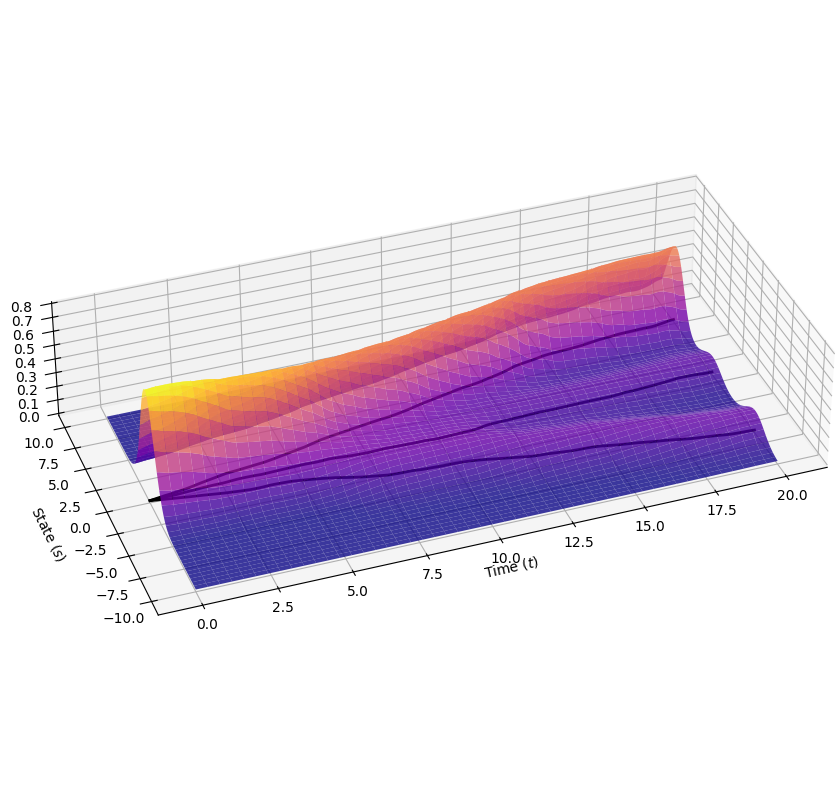

<Figure size 640x480 with 0 Axes>

In [115]:
weights = [0.85, 0.05, 0.1] 

for i in range(n_paths):
    mu_t = x_paths[i, :] 
    # Gaussian Component
    component_pdf = (1 / (prob_sigma * np.sqrt(2 * np.pi))) * \
                    np.exp(-((Y_mesh - mu_t)**2) / (2 * prob_sigma**2))
    Z_gmm += weights[i] * component_pdf

# --- Visualization ---
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Using the 'viridis' colormap
surf = ax.plot_surface(T_mesh, Y_mesh, Z_gmm, cmap='plasma', 
                       linewidth=0, antialiased=True, shade=False, alpha=0.8)

# Reference paths on the ground
for i in range(n_paths):
    ax.plot(t, x_paths[i], 0, color='black', lw=2, ls='-')

# Colorbar
# cbar = fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10, pad=0.1)
# cbar.set_label('GMM Probability Density')

# Axis formatting
ax.set_box_aspect((2, 1, 0.4))
# ax.set_title(f'GMM Trajectories (Higher Variance, Viridis Map)\n$\sigma_{{prob}}$ = {prob_sigma}', fontsize=14)
ax.set_xlabel(r'Time ($t$)')
ax.set_ylabel(r'State ($s$)')
ax.set_zlabel(r'$\pi$')
ax.view_init(elev=30, azim=-60)
ax.view_init(elev=35, azim=-110)

plt.tight_layout()
plt.show()
plt.savefig("Plot3D_UpdatedWeights.svg")
plt.savefig("Plot3D_UpdatedWeights.png")